In [92]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import convolve2d
from skimage.util import random_noise

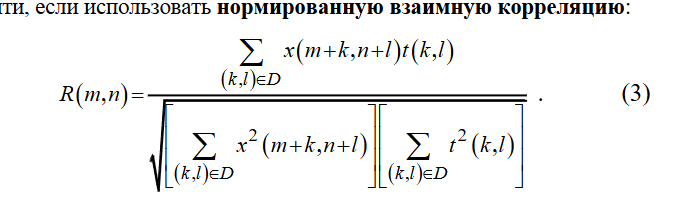

t - функцию яркости эталонного объекта


In [93]:
from scipy.signal import convolve2d
import numpy as np

def correlation_method(image, mask):
    # Нормализуем маску
    norm_mask = mask / np.sum(mask ** 2)
    rotate_norm_mask = np.flip(norm_mask)    
    # Вычисляем свертку для числителя
    numerator = convolve2d(image, rotate_norm_mask , mode='same')
    
    # Вычисляем энергию фрагментов для знаменателя
    image_squared = image ** 2
    window_ones = np.ones_like(mask)
    
    denominator = np.sqrt(convolve2d(image_squared, window_ones, mode='same'))
    denominator[denominator == 0] = 1
    
    R = numerator / denominator
    
    return R

In [94]:

def threshold_processing(image, threshold):
    result = (image > threshold).astype(np.uint8) * 255
    return result


def generate_noise(size, variance= 3000):
    msd = (variance**0.5) 
    image = np.full((size, size), 128)
    noise = (np.random.normal(0, 30, (size, size))).astype(np.int16)
    image += noise
    return image


def print_count_obj(bin_img, text="Количество обнаруженных объектов: "):
    count_find_obj = 0
    image_size = bin_img.shape
    for i in range(image_size[0]):
        for j in range(image_size[1]):
            if bin_img[i, j] == 255:
                count_find_obj += 1
    print(text + str(count_find_obj))


In [95]:
def add_objects(image, object_mask, count=15):
    image = image.copy()
    h, w = image.shape
    obj_h, obj_w = object_mask.shape
    
    for _ in range(count):
        y = np.random.randint(0, h - obj_h)
        x = np.random.randint(0, w - obj_w)
        
        image[y:y+obj_h, x:x+obj_w][object_mask == 1] = 255
    
    return image

In [96]:
def start(var = 3000):
    object_rotated_mask = np.array([
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0], 
    [1, 1, 1, 0, 0, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 0, 0, 1, 1, 1],
    [1, 1, 1, 0, 0, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 1, 0]])

    object_mask = np.array([
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 1, 1, 0, 0, 0, 1, 0], 
    [1, 1, 1, 0, 0, 0, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 0, 0, 1, 1, 1],
    [1, 1, 1, 0, 0, 1, 1, 1],
    [0, 1, 1, 0, 0, 1, 1, 0]])
    object_mask = np.array([[1, 1, 1], 
                            [0, 1, 0], 
                            [0, 1, 0]])
    
    object_rotated_mask = np.array([[0, 1, 0], 
                                    [0, 1, 0], 
                                    [1, 1, 1]])




    count = 4
    image_size = 32

    noise = generate_noise(image_size, var)

    image_with_same_object = add_objects(noise, object_mask, count=count)
    image_with_different_object = add_objects(image_with_same_object, object_rotated_mask, count=count)

    B_without_object = correlation_method(noise, object_mask)
    B_same_object = correlation_method(image_with_same_object, object_mask)
    B_different_object = correlation_method(image_with_different_object, object_mask)

    threshold = 0.4
    print("Максимальное значение корреляционного поля: " + str(threshold))
    founded_without_object = threshold_processing(B_without_object, threshold)
    founded_object_same = threshold_processing(B_same_object, threshold)
    founded_object_different = threshold_processing(B_different_object, threshold)

    print_count_obj(founded_without_object, "Количество обнаруженных объектов на изображении без объектов: ")
    print_count_obj(founded_object_same, "Количество обнаруженных объектов на изображении с одним объектом: ")
    print_count_obj(founded_object_different, "Количество обнаруженных объектов на изображении с двумя объектами: ")


    plt.figure(figsize=(16, 9))
    plt.suptitle("Фон без объектов", fontsize=19, fontweight='bold')

    plt.subplot(1, 3, 1)
    plt.title('Исходное изображение')
    plt.imshow(noise.astype(np.uint8), cmap='gray', vmin=0, vmax=255)

    plt.subplot(1, 3, 2)
    plt.title('Корреляционное поле')
    plt.imshow(B_without_object * 255, cmap='gray', vmin=0, vmax=255)

    plt.subplot(1, 3, 3)
    plt.title('Обнаруженные объекты')
    plt.imshow(founded_without_object, cmap='gray', vmin=0, vmax=255)
    plt.show()

    plt.figure(figsize=(16, 9))
    plt.suptitle("Объекты одного типа", fontsize=19, fontweight='bold')

    plt.subplot(2, 2, 1)
    plt.title('Исходное изображение фона')
    plt.imshow(noise.astype(np.uint8), cmap='gray', vmin=0, vmax=255)

    plt.subplot(2, 2, 2)
    plt.title('Изображение c объектами')
    plt.imshow(image_with_same_object, cmap='gray', vmin=0, vmax=255)

    plt.subplot(2, 2, 3)
    plt.title('Корреляционное поле')
    plt.imshow(B_same_object * 255, cmap='gray', vmin=0, vmax=255)

    plt.subplot(2, 2, 4)
    plt.title('Обнаруженные объекты')
    plt.imshow(founded_object_same, cmap='gray', vmin=0, vmax=255)
    plt.show()

    plt.figure(figsize=(16, 9))
    plt.suptitle("Объекты двух типов", fontsize=19, fontweight='bold')

    plt.subplot(2, 2, 1)
    plt.title('Исходное изображение фона')
    plt.imshow(noise.astype(np.uint8), cmap='gray', vmin=0, vmax=255)

    plt.subplot(2, 2, 2)
    plt.title('Изображение c объектами')
    plt.imshow(image_with_different_object, cmap='gray', vmin=0, vmax=255)

    plt.subplot(2, 2, 3)
    plt.title('Корреляционное поле')
    plt.imshow(B_different_object * 255, cmap='gray', vmin=0, vmax=255)

    plt.subplot(2, 2, 4)
    plt.title('Обнаруженные объекты')
    plt.imshow(founded_object_different, cmap='gray', vmin=0, vmax=255)
    plt.show()

Максимальное значение корреляционного поля: 0.4
Количество обнаруженных объектов на изображении без объектов: 0
Количество обнаруженных объектов на изображении с одним объектом: 4
Количество обнаруженных объектов на изображении с двумя объектами: 3


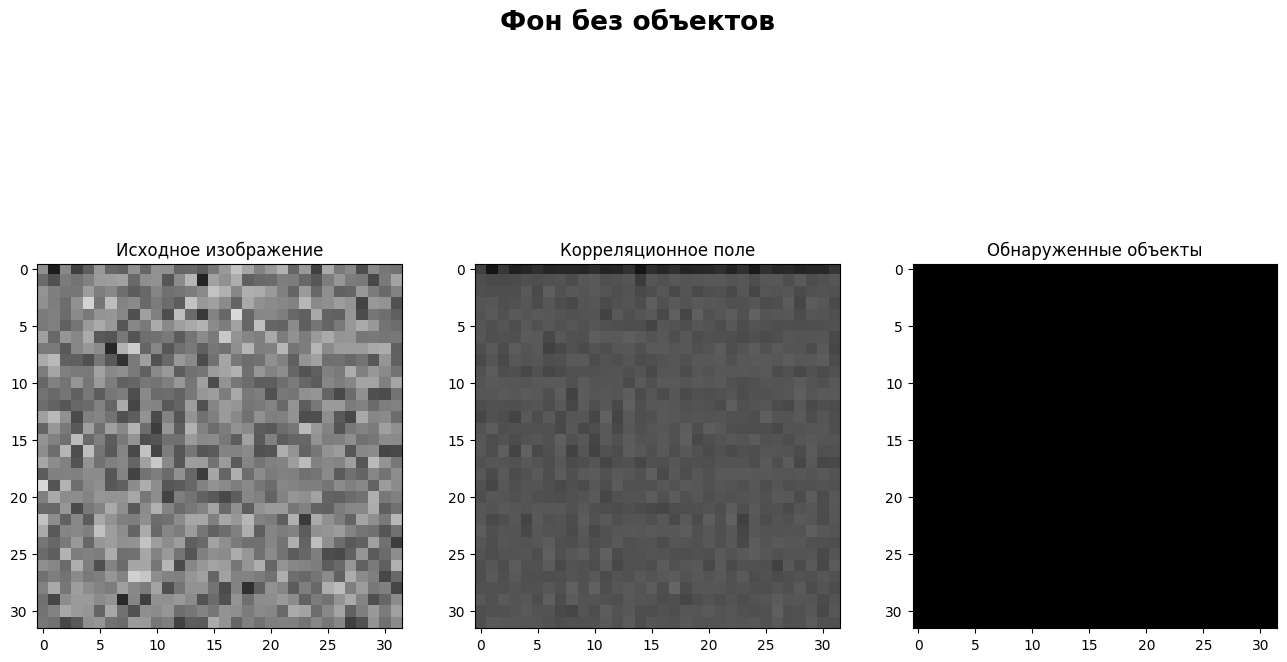

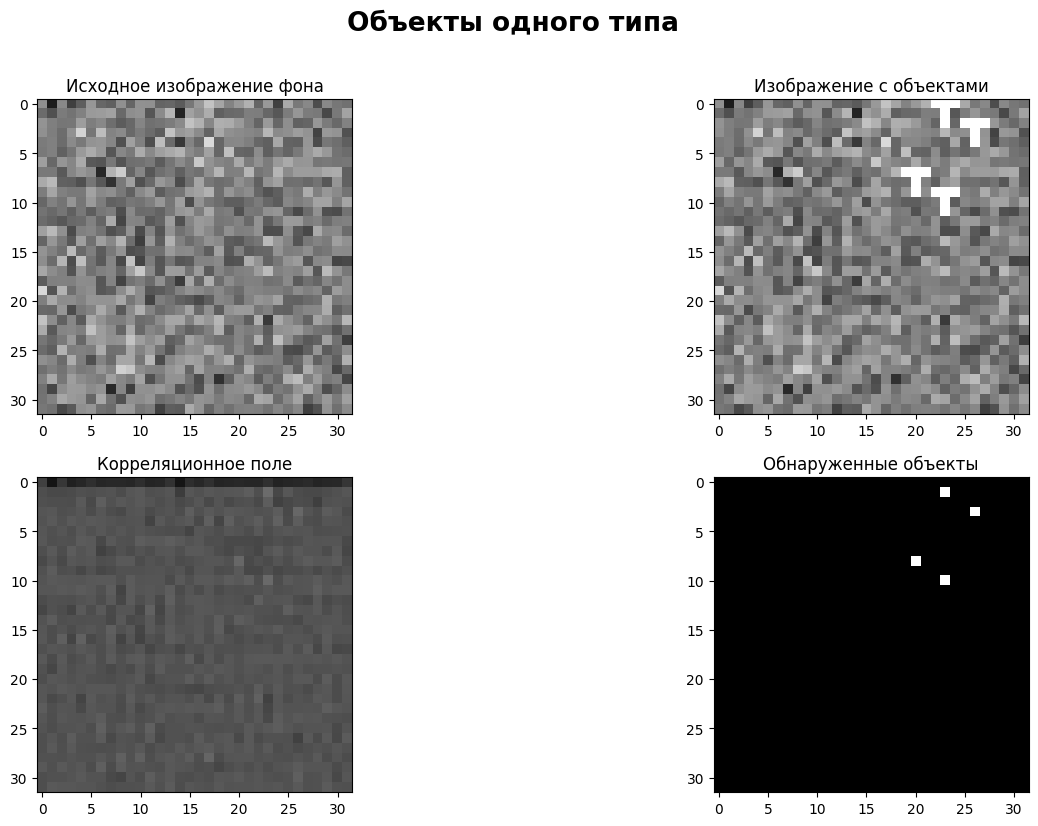

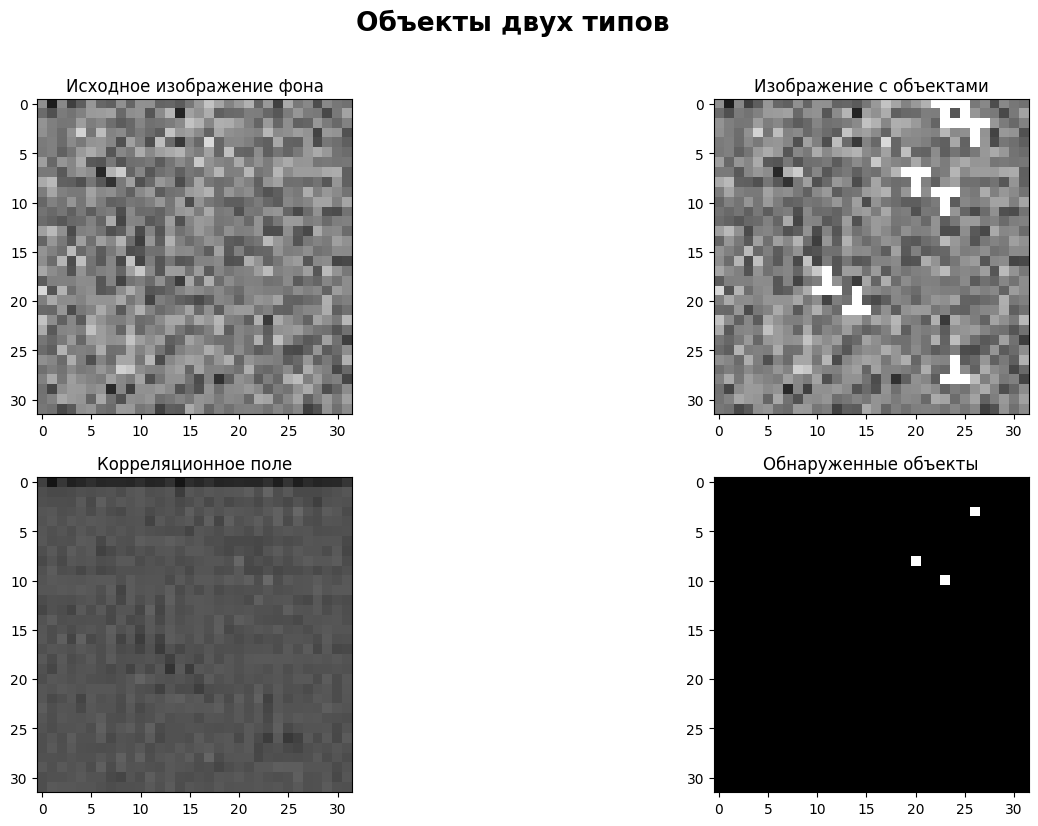

In [97]:
start(3000)

Максимальное значение корреляционного поля: 0.4
Количество обнаруженных объектов на изображении без объектов: 0
Количество обнаруженных объектов на изображении с одним объектом: 4
Количество обнаруженных объектов на изображении с двумя объектами: 3


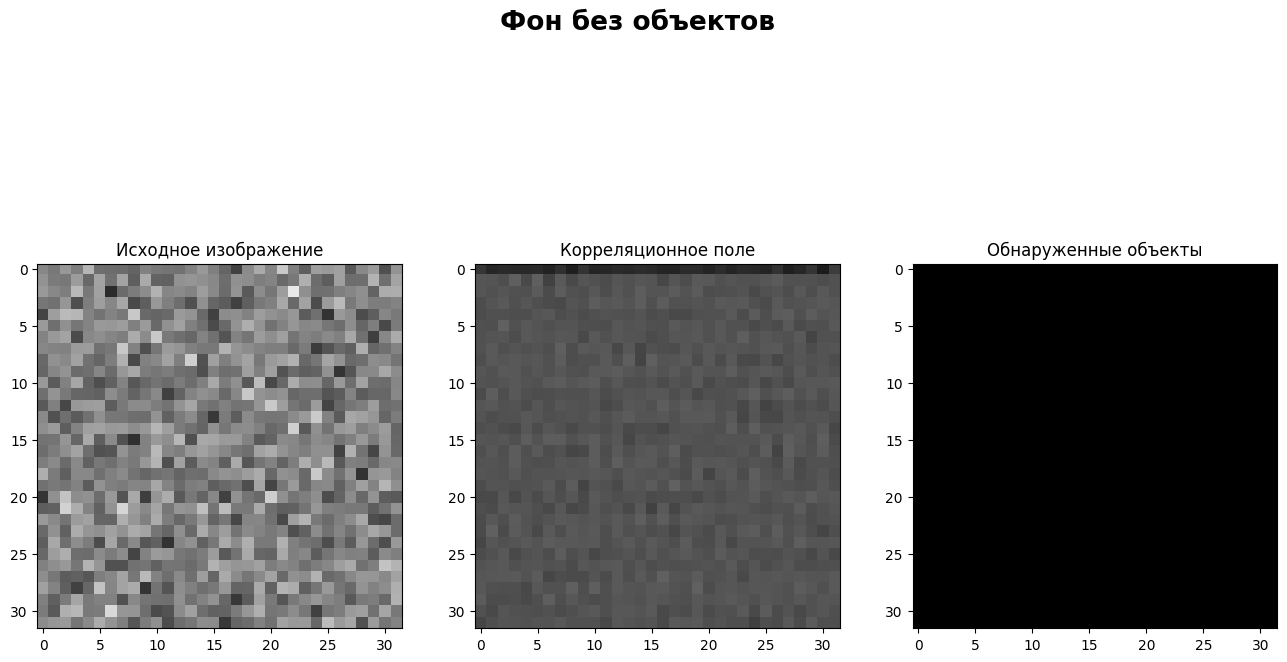

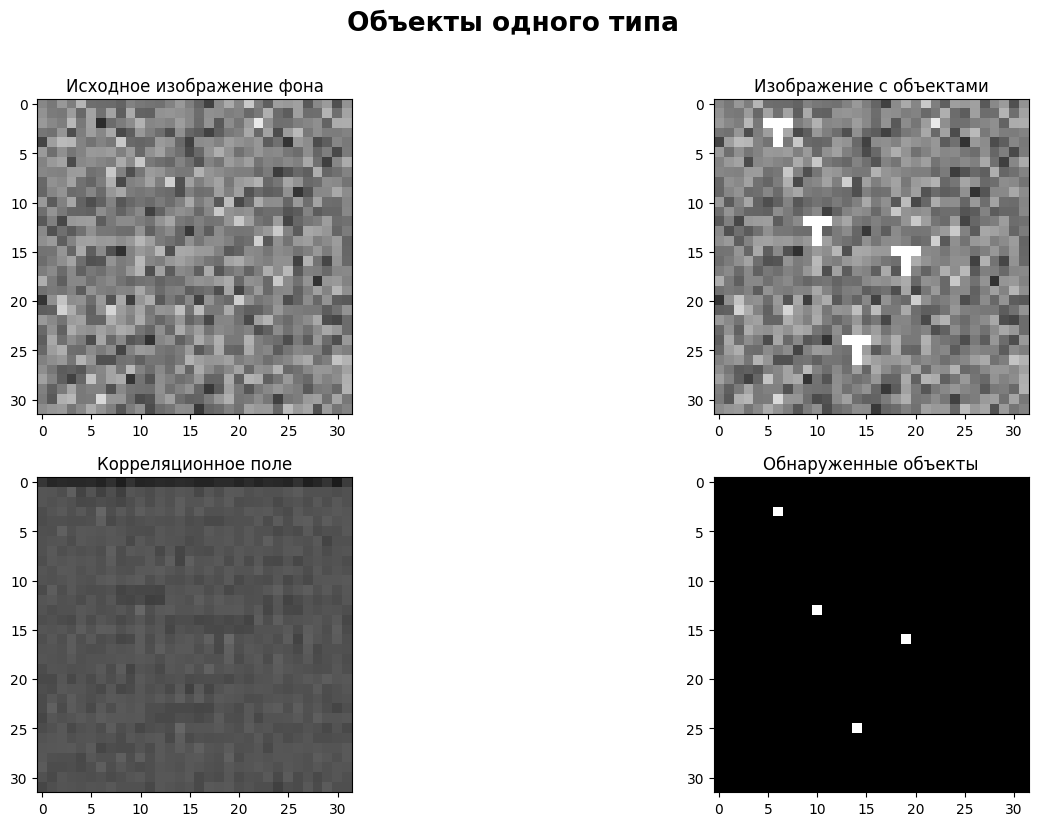

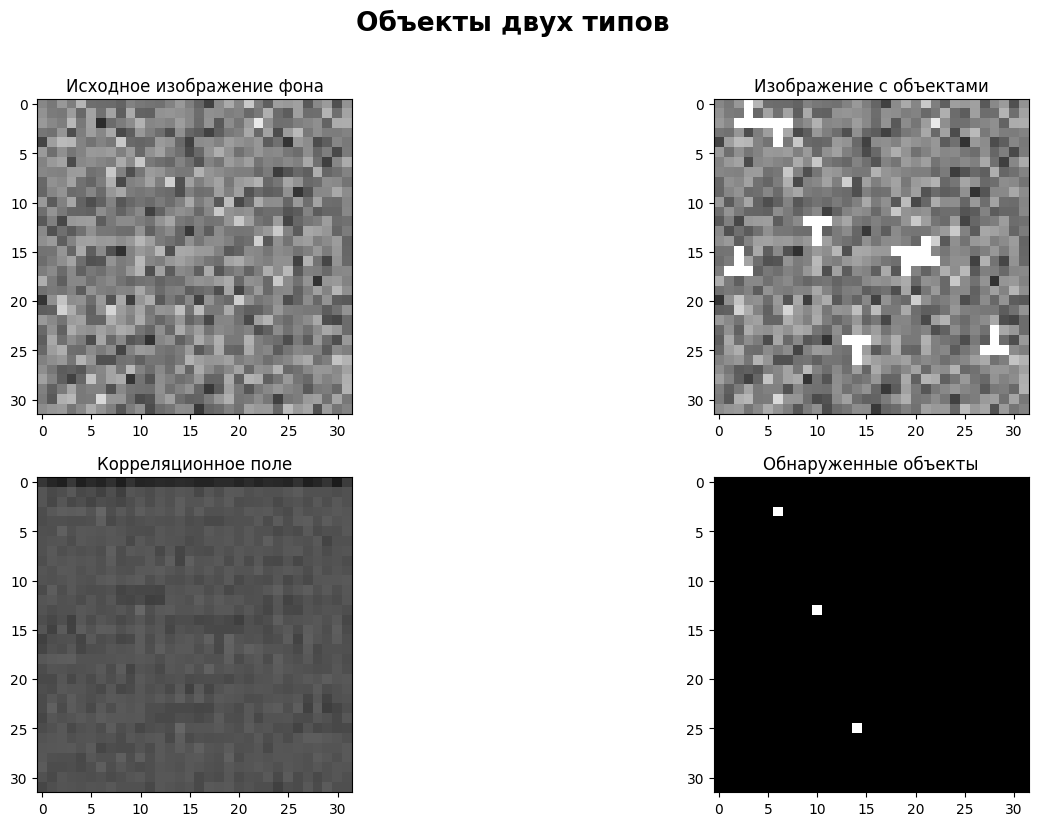

In [98]:
start(5000)